In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn


In [5]:
df = pd.read_csv('../data/dataset.csv')

df = df.drop(columns=["Unnamed: 0"])

In [6]:
target = "popularity"

features = [
    "duration_ms",
    "explicit",
    "danceability",
    "energy",
    "key",
    "loudness",
    "mode",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "time_signature",
    "track_genre"
]

X = df[features]
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (114000, 15)
y shape: (114000,)


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42
    )
    
print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 91200
Testing rows: 22800


In [8]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


# StandardScaler:
# Makes number columns easier for regression models to work with.

# OneHotEncoder:
# Turns track_genre into numeric columns.
# Example: pop, rap, rock, country become separate 0/1 columns.

# ColumnTransformer:
# Applies the right preprocessing to the right columns.

# Pipeline:
# Lets us combine preprocessing and the ML model into one clean object.

numeric_features = [
    "duration_ms",
    "danceability",
    "energy",
    "loudness",
    "mode",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "time_signature"
]

categorical_features = [
    "explicit",
    "track_genre"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [9]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

In [10]:
linear_model.fit(X_train, y_train)
ridge_model.fit(X_train, y_train)
random_forest_model.fit(X_train, y_train)

print("All models trained successfully.")

All models trained successfully.


In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(model, X_test, y_test, model_name):
    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)

    return {
        "Model" : model_name,
        "MAE" : mae,
        "MSE" : mse,
        "RMSE" : rmse,
        "R2 Score" : r2
    }

results = []
results.append(evaluate_model(linear_model, X_test, y_test, "Linear Regression"))
results.append(evaluate_model(ridge_model, X_test, y_test, "Ridge Regression"))
results.append(evaluate_model(random_forest_model, X_test, y_test, "Random Forest"))

results_df = pd.DataFrame(results)

results_df

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,14.084492,365.762050,19.124907,0.258812
1,Ridge Regression,14.087077,365.762342,19.124914,0.258812
2,Random Forest,10.314750,233.942003,15.295163,0.525935


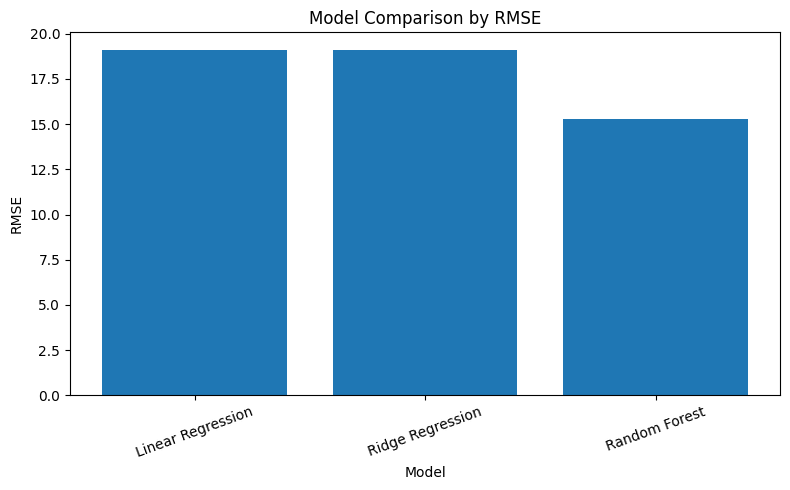

In [15]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.title("Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

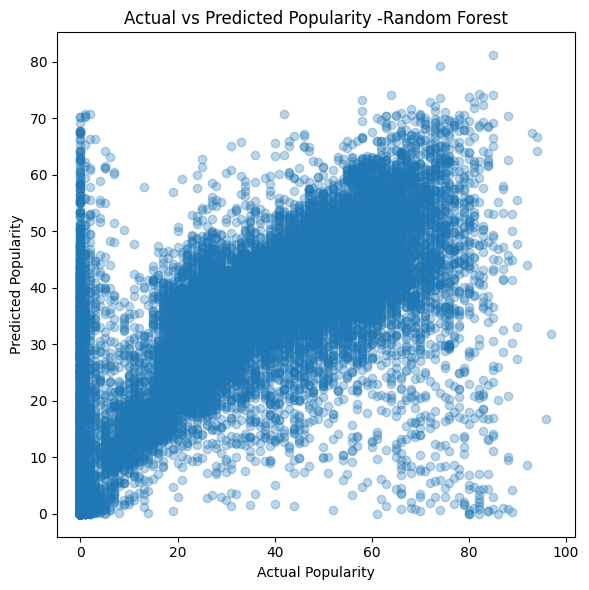

In [21]:
rf_predictions = random_forest_model.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, rf_predictions, alpha=0.3)
plt.xlabel("Actual Popularity")
plt.ylabel("Predicted Popularity")
plt.title("Actual vs Predicted Popularity -Random Forest")
plt.tight_layout()
plt.savefig("../images/actual_vs_predicted_rf.png", dpi=300, bbox_inches="tight")
plt.show()

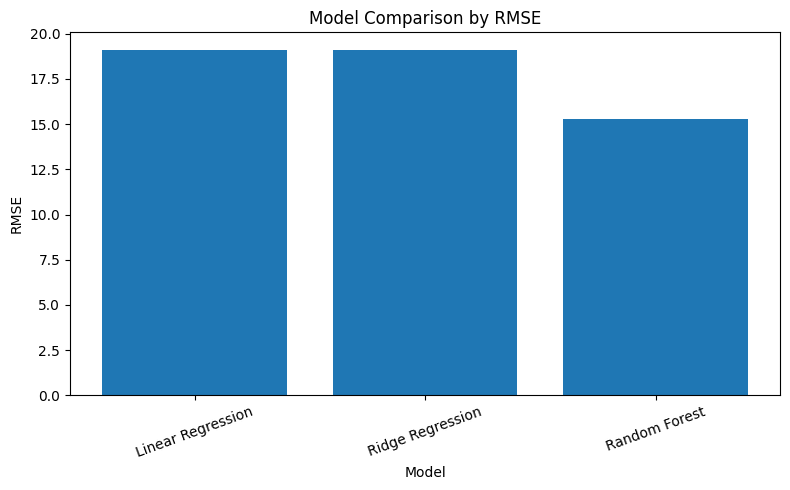

In [18]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.title("Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("../images/model_comparison_rmse.png", dpi=300, bbox_inches="tight")
plt.show()

In [19]:
# Get feature names after preprocessing
feature_names = random_forest_model.named_steps["preprocessor"].get_feature_names_out()

# Get importance values from the trained Random Forest model
importances = random_forest_model.named_steps["model"].feature_importances_

# Put feature names and importance values into a DataFrame
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort by most important features
feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

# Show top 15 features
feature_importance_df.head(15)

,Feature,Importance
0,num__duration_ms,0.071081
5,num__speechiness,0.071056
6,num__acousticness,0.070836
9,num__valence,0.069598
10,num__tempo,0.069458
1,num__danceability,0.069148
3,num__loudness,0.069036
2,num__energy,0.065344
8,num__liveness,0.061582
7,num__instrumentalness,0.048420


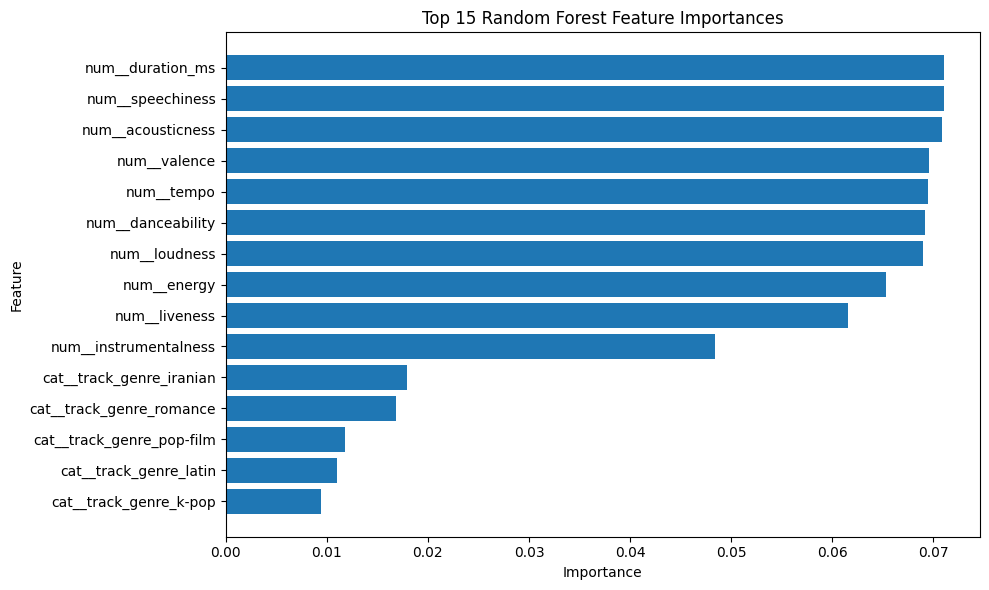

In [20]:
top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../images/random_forest_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()